In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("../data/results_clean.csv")

# --- 1. Visão geral ---
print("=== SHAPE ===")
print(df.shape)

print("\n=== DTYPES ===")
print(df.dtypes)

print("\n=== PRIMEIRAS LINHAS ===")
print(df.head(3).to_string())

print("\n=== VALORES NULOS ===")
print(df.isnull().sum())

print("\n=== ESTATÍSTICAS DESCRITIVAS ===")
print(df[["home_score", "away_score"]].describe().round(2))

=== SHAPE ===
(49476, 11)

=== DTYPES ===
date              str
home_team         str
away_team         str
home_score    float64
away_score    float64
tournament        str
city              str
country           str
neutral          bool
year            int64
decade          int64
dtype: object

=== PRIMEIRAS LINHAS ===
         date home_team away_team  home_score  away_score tournament     city   country  neutral  year  decade
0  1872-11-30  Scotland   England         0.0         0.0   Friendly  Glasgow  Scotland    False  1872    1870
1  1873-03-08   England  Scotland         4.0         2.0   Friendly   London   England    False  1873    1870
2  1874-03-07  Scotland   England         2.0         1.0   Friendly  Glasgow  Scotland    False  1874    1870

=== VALORES NULOS ===
date           0
home_team      0
away_team      0
home_score    44
away_score    44
tournament     0
city           0
country        0
neutral        0
year           0
decade         0
dtype: int64

=== ESTA

44 Nan são jogos futuros do mundial, ainda não jogados.

In [2]:
# --- 2. Duplicados ---
print("=== DUPLICADOS ===")
total_dup = df.duplicated().sum()
print(f"Linhas completamente duplicadas: {total_dup}")

# Duplicados por jogo (mesma data, mesmas equipas)
dup_jogos = df.duplicated(subset=["date", "home_team", "away_team"]).sum()
print(f"Jogos duplicados (date+home+away): {dup_jogos}")

# Ver os duplicados
if dup_jogos > 0:
    mask = df.duplicated(subset=["date", "home_team", "away_team"], keep=False)
    print("\nJogos duplicados:")
    print(df[mask].sort_values(["date", "home_team"]).to_string())

# --- 3. Outliers nos scores ---
print("\n=== OUTLIERS NOS SCORES ===")
outliers = df[
    (df["home_score"] >= 10) | (df["away_score"] >= 10)
].sort_values("home_score", ascending=False)
print(f"Jogos com score >= 10: {len(outliers)}")
print(outliers[["date", "home_team", "away_team", "home_score", "away_score", "tournament"]].head(15).to_string())

# --- 4. Distribuição temporal ---
df["date"] = pd.to_datetime(df["date"])
df["year"] = df["date"].dt.year

print("\n=== JOGOS POR DÉCADA ===")
df["decade"] = (df["year"] // 10) * 10
print(df["decade"].value_counts().sort_index())

=== DUPLICADOS ===
Linhas completamente duplicadas: 0
Jogos duplicados (date+home+away): 1

Jogos duplicados:
            date home_team      away_team  home_score  away_score tournament     city country  neutral  year  decade
9641  1974-02-17    Tahiti  New Caledonia         2.0         1.0   Friendly  Papeete  Tahiti    False  1974    1970
9642  1974-02-17    Tahiti  New Caledonia         1.0         2.0   Friendly  Papeete  Tahiti    False  1974    1970

=== OUTLIERS NOS SCORES ===
Jogos com score >= 10: 306
             date   home_team       away_team  home_score  away_score                                                tournament
25425  2001-04-11   Australia  American Samoa        31.0         0.0                              FIFA World Cup qualification
8551   1971-09-13      Tahiti    Cook Islands        30.0         0.0                                       South Pacific Games
11916  1979-08-30        Fiji        Kiribati        24.0         0.0                              

In [3]:
# --- 5. Tratar duplicado Gibraltar ---
# Manter apenas a primeira ocorrência do jogo duplicado com score igual
df = df.drop_duplicates(subset=["date", "home_team", "away_team", "home_score", "away_score"], keep="first")

# Verificar Tahiti 1974 — scores diferentes, manter ambos
tahiti = df[(df["home_team"] == "Tahiti") & (df["date"] == "1974-02-17")]
print("Tahiti 1974 após limpeza:")
print(tahiti[["date", "home_team", "away_team", "home_score", "away_score"]].to_string())

print(f"\nShape após remoção de duplicados: {df.shape}")
# Esperado: 49476 (removeu 1 linha — o Gibraltar duplicado)

# --- 6. Guardar dataset limpo ---
df.to_csv("../data/results_clean.csv", index=False)
print("Guardado: results_clean.csv")

Tahiti 1974 após limpeza:
           date home_team      away_team  home_score  away_score
9641 1974-02-17    Tahiti  New Caledonia         2.0         1.0
9642 1974-02-17    Tahiti  New Caledonia         1.0         2.0

Shape após remoção de duplicados: (49476, 11)
Guardado: results_clean.csv


=== DISTRIBUIÇÃO DE RESULTADOS (histórico completo) ===
resultado
H    24226
A    13963
D    11243
Name: count, dtype: int64

% H: 49.0%
% D: 22.7%
% A: 28.2%


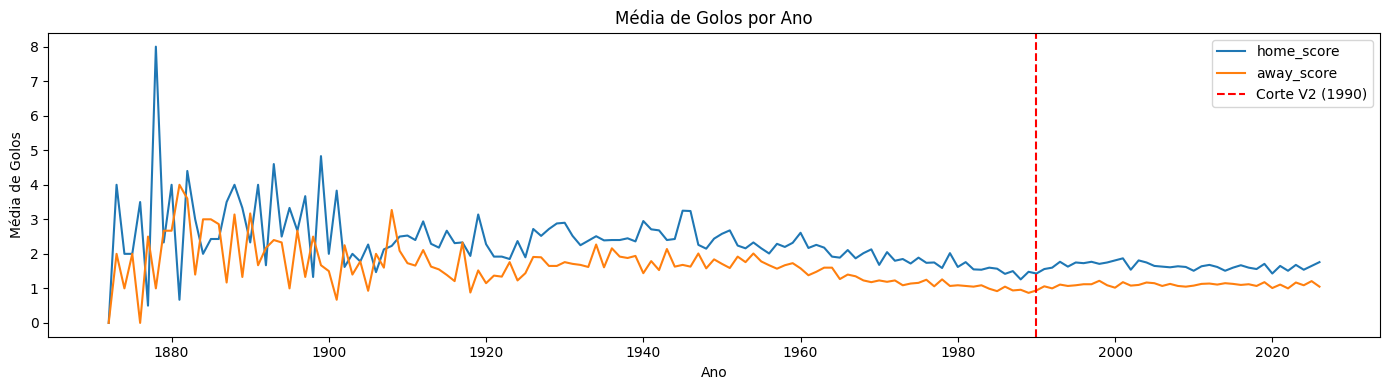


=== TOP 20 EQUIPAS POR Nº DE JOGOS ===
home_team
Sweden         1104
England        1093
Argentina      1072
Brazil         1062
Germany        1034
South Korea    1010
Mexico         1006
Hungary        1006
Uruguay         973
France          938
Italy           893
Poland          892
Switzerland     887
Netherlands     882
Norway          875
Denmark         874
Thailand        865
Austria         863
Belgium         856
Scotland        854
Name: count, dtype: int64

=== JOGOS COM SCORES NEGATIVOS ===
0

=== JOGOS COM SCORES NaN (futuros) ===
            date home_team   away_team      tournament
49471 2026-06-27    Jordan   Argentina  FIFA World Cup
49472 2026-06-27  Colombia    Portugal  FIFA World Cup
49473 2026-06-27  DR Congo  Uzbekistan  FIFA World Cup
49474 2026-06-27    Panama     England  FIFA World Cup
49475 2026-06-27   Croatia       Ghana  FIFA World Cup

=== EDA CONCLUÍDA ===
Dataset limpo: 49476 linhas, 11 colunas
Jogos com resultado: 49432
Jogos futuros (NaN): 44


In [4]:
# --- 7. Distribuição de resultados ---
df_played = df[df["home_score"].notna()].copy()

df_played["resultado"] = df_played.apply(
    lambda r: "H" if r["home_score"] > r["away_score"]
    else ("D" if r["home_score"] == r["away_score"] else "A"),
    axis=1
)

print("=== DISTRIBUIÇÃO DE RESULTADOS (histórico completo) ===")
print(df_played["resultado"].value_counts())
print(f"\n% H: {(df_played['resultado']=='H').mean():.1%}")
print(f"% D: {(df_played['resultado']=='D').mean():.1%}")
print(f"% A: {(df_played['resultado']=='A').mean():.1%}")

# --- 8. Média de golos por época ---
df_played["year"] = pd.to_datetime(df_played["date"]).dt.year
golos_ano = df_played.groupby("year")[["home_score","away_score"]].mean().round(2)

fig, ax = plt.subplots(figsize=(14,4))
golos_ano.plot(ax=ax)
ax.set_title("Média de Golos por Ano")
ax.set_xlabel("Ano")
ax.set_ylabel("Média de Golos")
ax.axvline(1990, color="red", linestyle="--", label="Corte V2 (1990)")
ax.legend()
plt.tight_layout()
plt.show()

# --- 9. Top equipas com mais jogos ---
home_counts = df["home_team"].value_counts()
away_counts = df["away_team"].value_counts()
total_games = (home_counts.add(away_counts, fill_value=0)).astype(int).sort_values(ascending=False)

print("\n=== TOP 20 EQUIPAS POR Nº DE JOGOS ===")
print(total_games.head(20))

# --- 10. Consistência de scores ---
print("\n=== JOGOS COM SCORES NEGATIVOS ===")
print(df[(df["home_score"] < 0) | (df["away_score"] < 0)].shape[0])

print("\n=== JOGOS COM SCORES NaN (futuros) ===")
print(df[df["home_score"].isna()][["date","home_team","away_team","tournament"]].tail(5).to_string())

print("\n=== EDA CONCLUÍDA ===")
print(f"Dataset limpo: {df.shape[0]} linhas, {df.shape[1]} colunas")
print(f"Jogos com resultado: {df_played.shape[0]}")
print(f"Jogos futuros (NaN): {df['home_score'].isna().sum()}")

Resumo das conclusões:
Qualidade dos dados — tudo limpo:

0 scores negativos
1 duplicado real removido (Gibraltar)
44 NaN são jogos futuros do Mundial — esperado e correcto

Top 20 equipas — nota interessante:

Suécia com mais jogos (1104) — surpreendente, reflexo de décadas de jogos activos
Thailand (865) — volume alto por participação em muitas qualificações asiáticas
Todas as grandes potências presentes no top 20

In [6]:
df.to_csv("../data/results_clean.csv", index=False)
df["date"] = pd.to_datetime(df["date"])
df["year"] = df["date"].dt.year
df["decade"] = (df["year"] // 10) * 10

df_played = df[df["home_score"].notna()].copy()
df_played["resultado"] = df_played.apply(
    lambda r: "H" if r["home_score"] > r["away_score"]
    else ("D" if r["home_score"] == r["away_score"] else "A"),
    axis=1
)
df_played["total_golos"] = df_played["home_score"] + df_played["away_score"]

In [ ]:
# --- 1. Distribuição H/D/A por tipo de torneio ---
print("=== H/D/A POR TIPO DE TORNEIO ===")
tour_result = (
    df_played.groupby("tournament")["resultado"]
    .value_counts(normalize=True)
    .unstack()
    .fillna(0)
    .round(3)
)
# Filtrar só torneios com >100 jogos
tour_counts = df_played["tournament"].value_counts()
top_tours = tour_counts[tour_counts > 100].index
print(tour_result.loc[tour_result.index.isin(top_tours)].sort_values("H", ascending=False).head(15).to_string())

=== H/D/A POR TIPO DE TORNEIO ===
resultado                                 A      D      H
tournament                                               
Southeast Asian Games                 0.170  0.198  0.632
CCCF Championship                     0.276  0.138  0.585
AFC Asian Cup qualification           0.251  0.165  0.584
Indian Ocean Island Games             0.182  0.236  0.582
Oceania Nations Cup                   0.324  0.101  0.576
UNCAF Cup                             0.207  0.220  0.573
AFF Championship                      0.247  0.203  0.550
African Cup of Nations qualification  0.206  0.245  0.549
Island Games                          0.332  0.119  0.548
Korea Cup                             0.258  0.200  0.542
Central European International Cup    0.230  0.230  0.540
South Pacific Games                   0.356  0.112  0.532
Muratti Vase                          0.405  0.064  0.532
Gold Cup                              0.264  0.205  0.531
SAFF Cup                              

In [7]:
# --- 2. Distribuição H/D/A por década ---
print("\n=== H/D/A POR DÉCADA ===")
decade_result = (
    df_played.groupby("decade")["resultado"]
    .value_counts(normalize=True)
    .unstack()
    .fillna(0)
    .round(3)
)

print(decade_result.to_string())


=== H/D/A POR DÉCADA ===
resultado      A      D      H
decade                        
1870       0.231  0.154  0.615
1880       0.418  0.091  0.491
1890       0.339  0.153  0.508
1900       0.377  0.174  0.449
1910       0.294  0.161  0.545
1920       0.290  0.179  0.531
1930       0.316  0.159  0.525
1940       0.313  0.154  0.533
1950       0.326  0.184  0.490
1960       0.280  0.196  0.523
1970       0.281  0.218  0.501
1980       0.267  0.261  0.471
1990       0.260  0.243  0.497
2000       0.279  0.235  0.487
2010       0.288  0.233  0.479
2020       0.292  0.231  0.477


Três tendências confirmadas:

H decresce progressivamente — futebol mais equilibrado
D aumenta progressivamente — mais táctica e defensiva
A relativamente estável mas com ligeira subida depois de descer nos anos 50

Implicação directa para o modelo:

O modelo foi treinado com dados pós-1990 onde H≈48%, D≈24%, A≈28%. O conjunto de teste (Mundial 2026) tem H=53%, D=36%, A=11% — distribuição muito diferente. Isto explica parcialmente porque o modelo tem dificuldade com empates no teste.

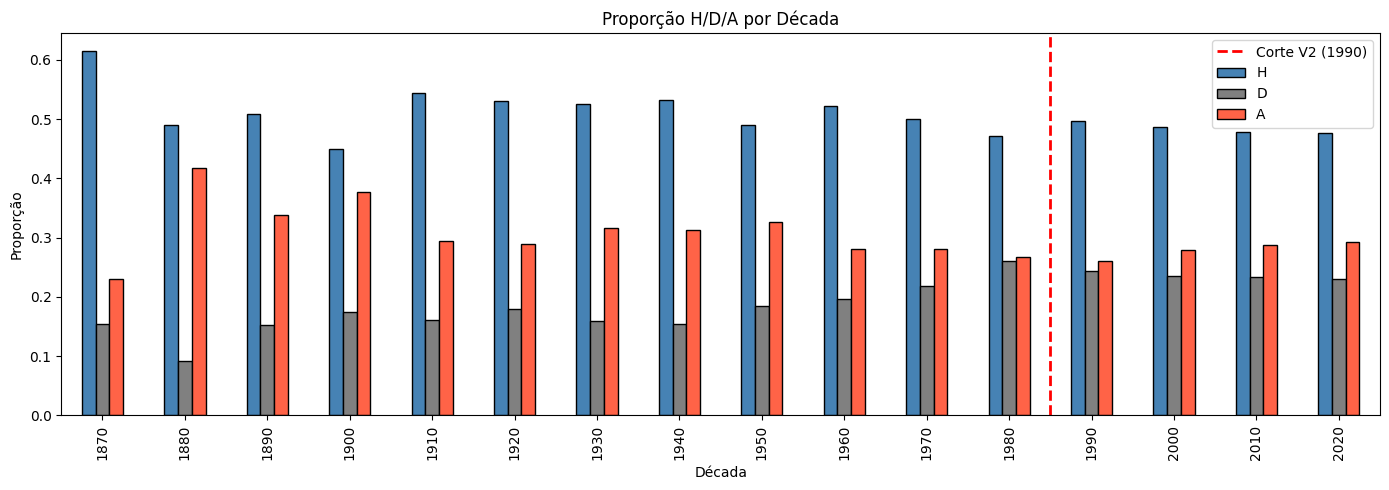

In [8]:
# --- 3. Gráfico H/D/A por década ---
fig, ax = plt.subplots(figsize=(14, 5))
decade_result[["H", "D", "A"]].plot(
    kind="bar", ax=ax,
    color=["steelblue", "grey", "tomato"],
    edgecolor="black"
)
ax.axvline(x=decade_result.index.get_loc(1990) - 0.5,
           color="red", linestyle="--", linewidth=2, label="Corte V2 (1990)")
ax.set_title("Proporção H/D/A por Década")
ax.set_xlabel("Década")
ax.set_ylabel("Proporção")
ax.legend()
plt.tight_layout()
plt.show()

Vantagem home consistente em todas as décadas — H nunca desce abaixo de 47%

Pós-1990 (corte V2): H desce ligeiramente (~48%) e A sobe (~28%) — o futebol moderno é mais equilibrado

Empates (D) aumentaram progressivamente — de ~15% nos anos 1870 para ~23% pós-1990. O futebol moderno é mais táctico e defensivo

Décadas 1870-1900: poucos jogos, alta variância — reforça o corte em 1990

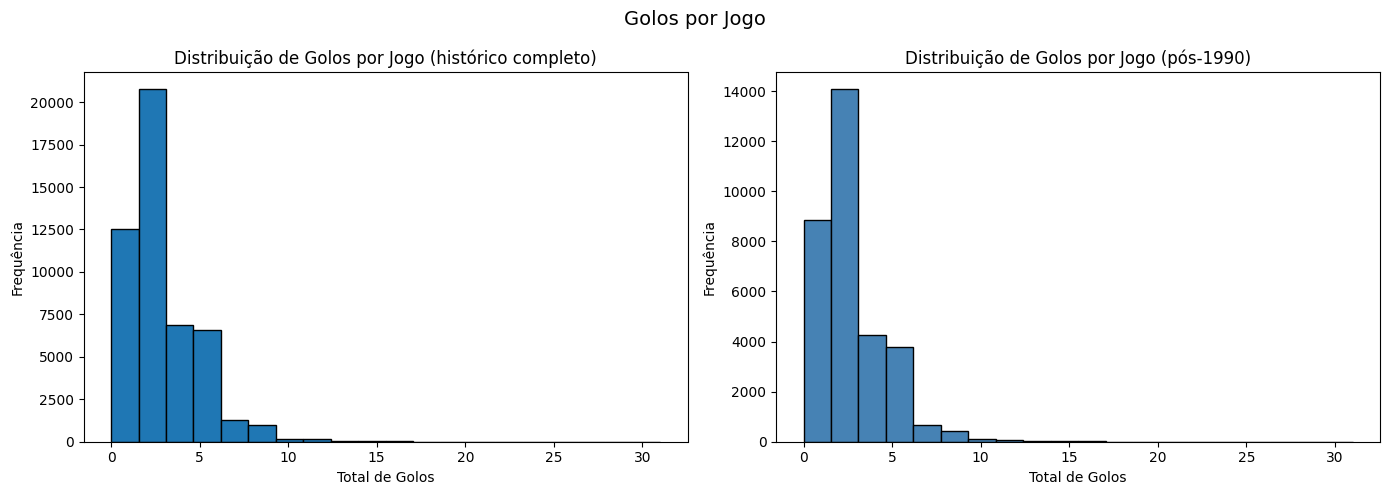

In [9]:
# --- 4. Distribuição de golos totais por jogo ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_played["total_golos"], bins=20, edgecolor="black")
axes[0].set_title("Distribuição de Golos por Jogo (histórico completo)")
axes[0].set_xlabel("Total de Golos")
axes[0].set_ylabel("Frequência")

# Pós-1990
df_modern = df_played[df_played["year"] >= 1990]
axes[1].hist(df_modern["total_golos"], bins=20, edgecolor="black", color="steelblue")
axes[1].set_title("Distribuição de Golos por Jogo (pós-1990)")
axes[1].set_xlabel("Total de Golos")
axes[1].set_ylabel("Frequência")

plt.suptitle("Golos por Jogo", fontsize=14)
plt.tight_layout()
plt.show()


distribuição de Poisson clara:

Pico em 2-3 golos, cauda longa à direita

Pós-1990 praticamente idêntico ao histórico completo — o padrão de golos é estável

Valida a escolha do Poisson Regressor para o modelo de regressão

In [10]:
# --- 5. Taxa de vitória home por neutral ---
print("\n=== TAXA DE VITÓRIA HOME: CAMPO NEUTRO VS NÃO-NEUTRO ===")
neutral_result = (
    df_played.groupby("neutral")["resultado"]
    .value_counts(normalize=True)
    .unstack()
    .fillna(0)
    .round(3)
)
neutral_result.index = ["Campo Não-Neutro", "Campo Neutro"]
print(neutral_result.to_string())

# --- 6. Top 20 equipas com maior taxa de vitória home ---
print("\n=== TOP 20 EQUIPAS — MAIOR TAXA VITÓRIA HOME (min 50 jogos) ===")
home_wins = df_played.groupby("home_team").apply(
    lambda x: pd.Series({
        "jogos": len(x),
        "vitorias": (x["resultado"] == "H").sum(),
        "taxa_vitoria": (x["resultado"] == "H").mean().round(3)
    })
).query("jogos >= 50").sort_values("taxa_vitoria", ascending=False)
print(home_wins.head(20).to_string())


=== TAXA DE VITÓRIA HOME: CAMPO NEUTRO VS NÃO-NEUTRO ===
resultado             A      D      H
Campo Não-Neutro  0.264  0.229  0.507
Campo Neutro      0.334  0.224  0.442

=== TOP 20 EQUIPAS — MAIOR TAXA VITÓRIA HOME (min 50 jogos) ===
                  jogos  vitorias  taxa_vitoria
home_team                                      
Brazil            615.0     438.0         0.712
Jersey            129.0      90.0         0.698
Spain             410.0     281.0         0.685
Argentina         607.0     409.0         0.674
Guernsey          132.0      87.0         0.659
Egypt             444.0     292.0         0.658
Ivory Coast       323.0     211.0         0.653
Czech Republic    178.0     116.0         0.652
Morocco           346.0     222.0         0.642
Iran              350.0     223.0         0.637
Nigeria           318.0     201.0         0.632
Italy             492.0     310.0         0.630
Ghana             315.0     197.0         0.625
England           551.0     343.0         0

Top 20 taxa vitória home:

Brasil (71.2%) e Argentina (67.4%) — dominância histórica em casa validada

Jersey e Guernsey no top — territórios não-FIFA com jogos regionais fáceis, viés esperado

Marrocos (64.2%), Egipto (65.8%), Costa do Marfim (65.3%) — África forte em casa

In [11]:
# --- Torneios principais explicitamente ---
torneios_principais = [
    "FIFA World Cup",
    "UEFA Euro",
    "Copa América",
    "African Cup of Nations",
    "AFC Asian Cup",
    "Gold Cup",
    "UEFA Nations League",
    "FIFA World Cup qualification",
    "UEFA Euro qualification",
    "Friendly",
]

print("=== H/D/A — TORNEIOS PRINCIPAIS ===")
resultado_principais = (
    df_played[df_played["tournament"].isin(torneios_principais)]
    .groupby("tournament")["resultado"]
    .value_counts(normalize=True)
    .unstack()
    .fillna(0)
    .round(3)
)[["H", "D", "A"]]

# Adicionar contagem de jogos
resultado_principais["n_jogos"] = df_played[
    df_played["tournament"].isin(torneios_principais)
].groupby("tournament")["resultado"].count()

print(resultado_principais.sort_values("H", ascending=False).to_string())

=== H/D/A — TORNEIOS PRINCIPAIS ===
resultado                         H      D      A  n_jogos
tournament                                                
Gold Cup                      0.531  0.205  0.264      420
Copa América                  0.509  0.216  0.275      869
FIFA World Cup qualification  0.508  0.211  0.280     8771
UEFA Euro qualification       0.486  0.196  0.318     2824
Friendly                      0.473  0.251  0.276    18387
AFC Asian Cup                 0.463  0.238  0.299      421
FIFA World Cup                0.458  0.226  0.317      992
African Cup of Nations        0.449  0.286  0.265      845
UEFA Nations League           0.430  0.251  0.319      658
UEFA Euro                     0.394  0.263  0.343      388


UEFA Euro tem H mais baixo (39.4%) que o Mundial (45.8%) — surpreendente. 

Pode ser porque o Euro concentra as melhores equipas do mundo numa única confederação — jogos muito mais equilibrados. No Mundial há mais desequilíbrios entre confederações.

FIFA World Cup: A=31.7% — claramente acima da média histórica (28%). 

Confirma que campo neutro favorece o visitante. O Fator_Casa=0 no simulador está correcto.

O modelo foi treinado com Qualificação (H=50.8%) como maioria dos dados — mas vai prever jogos do Mundial (H=45.8%, A=31.7%). Há um shift de distribuição que o modelo não compensa completamente

Dar mais peso aos jogos do Mundial no treino — actualmente são apenas 542 dos 17.563 jogos (3%). Um class_weight ou sample_weight proporcional ao tipo de competição poderia ajudar.